In [6]:
!pip install -q transformers accelerate Pillow matplotlib
!pip install -U "bitsandbytes>=0.46.1"
!git clone https://github.com/sht037-lgtm/Q-Vtree.git
%cd Q-Vtree

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.6 MB/s eta 0:00:00:00:0100:01
Cloning into 'Q-Vtree'...
remote: Enumerating objects: 1104, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 1104 (delta 49), reused 49 (delta 24), pack-reused 1029 (from 2)
Receiving objects: 100% (1104/1104), 35.80 MiB | 52.67 MiB/s, done.
Resolving deltas: 100% (680/680), done.
/kaggle/working/Q-Vtree


In [7]:
from transformers import LlavaForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
import torch

model_id  = "llava-hf/llava-1.5-7b-hf"
bnb_config = BitsAndBytesConfig(load_in_4bit=True)

processor = AutoProcessor.from_pretrained(model_id)
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    attn_implementation="eager",
)
model.eval()
print("Model loaded")

processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

Model loaded


Image size: (1120, 1120)


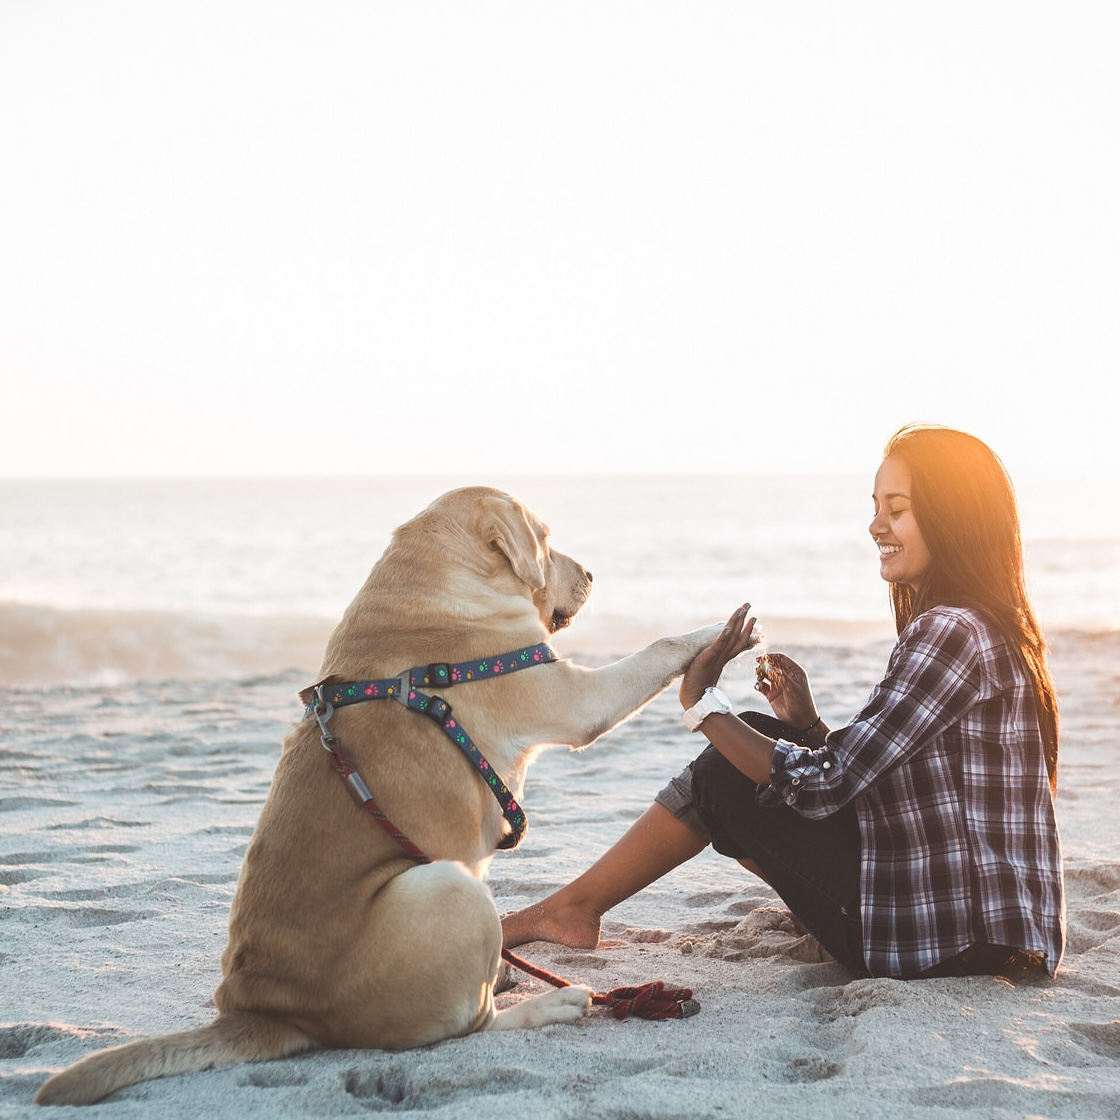

In [8]:
from PIL import Image

image    = Image.open("img/demo_2.jpeg").convert("RGB")
question = (
    "What breed is the dog in the image?\n"
    "(A) Labrador\n(B) Husky\n(C) Poodle\n(D) Corgi\n"
    "Answer with the option's letter from the given choices directly."
)
print("Image size:", image.size)
image

import 成功
[INFO] Forward pass 1: specific question
[DEBUG] answer token = 'A'
[DEBUG] seq_len = 640, ans_pos = 639
[DEBUG] num image tokens = 576
[DEBUG] A_q   max=0.007898, mean=0.00005785
[INFO] Forward pass 2: generic question
[DEBUG] answer token = 'The'
[DEBUG] seq_len = 594, ans_pos = 593
[DEBUG] num image tokens = 576
[DEBUG] A_q0  max=0.009883, mean=0.00012408
[DEBUG] relative max=3.1645, mean=0.740505
[INFO] Saved to attention_map_v3.png


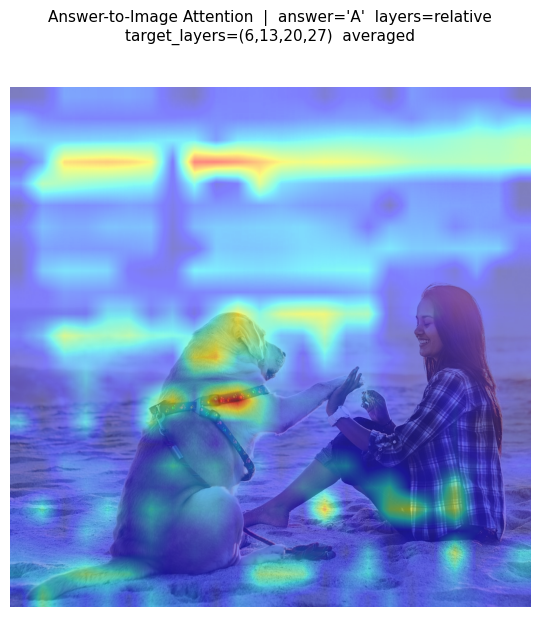

In [15]:
import importlib.util, sys

# 直接从绝对路径加载模块
spec = importlib.util.spec_from_file_location(
    "attention_viz",
    "/kaggle/working/Q-Vtree/LLaVA/attention_viz.py"
)
attention_viz = importlib.util.module_from_spec(spec)
spec.loader.exec_module(attention_viz)

get_attention_maps = attention_viz.get_attention_maps
visualize_attention = attention_viz.visualize_attention
print("import 成功")

attn_result = get_attention_maps(
    model=model,
    processor=processor,
    image=image,
    question=question,
    target_layers=(6, 13, 20, 27),
    use_relative=True,
)

visualize_attention(
    image=image,
    attn_result=attn_result,
    alpha=0.5,
    save_path="attention_map_v3.png",
)